In [2]:
import pandas as pd
df = pd.read_csv("battery_stats_cycles_001_750.csv")

print(f"{df.shape[0]}")

print(f"\n{df.head()}")

92717

   cycle_number  voltage_v sample_number  discharge_energy_wh  temperature_c  \
0           1.0   3.669531        01-001             9.198724           10.0   
1           2.0   3.664757        01-001             9.472517           10.0   
2           3.0   3.659098        01-001             9.566450           10.0   
3           4.0   3.655673        01-001             9.611696           10.0   
4           5.0   3.653233        01-001             9.635559           10.0   

   cycle_number_local   source_folder               source_file   source_sheet  
0                 1.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
1                 2.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
2                 3.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
3                 4.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
4                 5.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  


In [3]:
charge_cutoff=['C/5','C/40']
discharge_rate=[0.7,1,2]
temp=[10,25,45,60]
table_list=[]
i=1
for t in temp:
    for d in discharge_rate:
        for c in charge_cutoff:
            table_list.append({'Condition':i, 'Temperature':t, 'Discharge Rate':d, 'Charge Cutoff':c})
            i += 1
cond_guide=pd.DataFrame(table_list)
cond_guide.head(24)


,Condition,Temperature,Discharge Rate,Charge Cutoff
0,1,10,0.7,C/5
1,2,10,0.7,C/40
2,3,10,1.0,C/5
3,4,10,1.0,C/40
4,5,10,2.0,C/5
5,6,10,2.0,C/40
6,7,25,0.7,C/5
7,8,25,0.7,C/40
8,9,25,1.0,C/5
9,10,25,1.0,C/40


In [4]:
# Map df sample prefix (before '-') to cond_guide Condition
# Example: sample_number '01-001' -> condition_id 1

df = df.copy()

# Make this cell rerun-safe by removing prior mapping columns/suffixes
cols_to_remove = [
    c for c in df.columns
    if c in {'condition_id', 'discharge_rate', 'charge_cutoff'}
    or c.startswith('discharge_rate_')
    or c.startswith('charge_cutoff_')
]
if cols_to_remove:
    df = df.drop(columns=cols_to_remove)

# 1) Extract condition id from sample_number prefix
#    Handles values like '01-001', '12-089', etc.
df['condition_id'] = (
    df['sample_number']
    .astype(str)
    .str.extract(r'^(\d+)')[0]
    .astype('Int64')
)

# 2) Prepare lookup table from cond_guide
cond_lookup = cond_guide.rename(columns={
    'Condition': 'condition_id',
    'Discharge Rate': 'discharge_rate',
    'Charge Cutoff': 'charge_cutoff'
})[['condition_id', 'discharge_rate', 'charge_cutoff']].copy()

cond_lookup['condition_id'] = pd.to_numeric(cond_lookup['condition_id'], errors='coerce').astype('Int64')

# 3) Merge to add discharge_rate and charge_cutoff columns
#    validate='m:1' ensures each condition_id maps to at most one row in cond_guide
df = df.merge(cond_lookup, on='condition_id', how='left', validate='m:1')

print(df[['sample_number', 'condition_id', 'discharge_rate', 'charge_cutoff']].head(12))
print('\nMissing mapping rows:', int(df['discharge_rate'].isna().sum()))

df.to_csv("battery_stats_cycles_001_750_mapped.csv", index=False)

   sample_number  condition_id  discharge_rate charge_cutoff
0         01-001             1             0.7           C/5
1         01-001             1             0.7           C/5
2         01-001             1             0.7           C/5
3         01-001             1             0.7           C/5
4         01-001             1             0.7           C/5
5         01-001             1             0.7           C/5
6         01-001             1             0.7           C/5
7         01-001             1             0.7           C/5
8         01-001             1             0.7           C/5
9         01-001             1             0.7           C/5
10        01-001             1             0.7           C/5
11        01-001             1             0.7           C/5

Missing mapping rows: 0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("battery_stats_cycles_001_750_mapped.csv")
target_col=['discharge_energy_wh']
feature_cols=['cycle_number','sample_number','voltage_v','temperature_c','discharge_rate','charge_cutoff']
print(df.shape)
print(df['discharge_energy_wh'].describe())
missing=df.isnull().sum().sort_values(ascending=False)
print(f'\n{missing}')


(92717, 12)
count    92717.000000
mean         9.593251
std          2.349228
min          0.000000
25%          8.952688
50%         10.352730
75%         11.131760
max         12.860190
Name: discharge_energy_wh, dtype: float64

cycle_number           0
voltage_v              0
sample_number          0
discharge_energy_wh    0
temperature_c          0
cycle_number_local     0
source_folder          0
source_file            0
source_sheet           0
condition_id           0
discharge_rate         0
charge_cutoff          0
dtype: int64


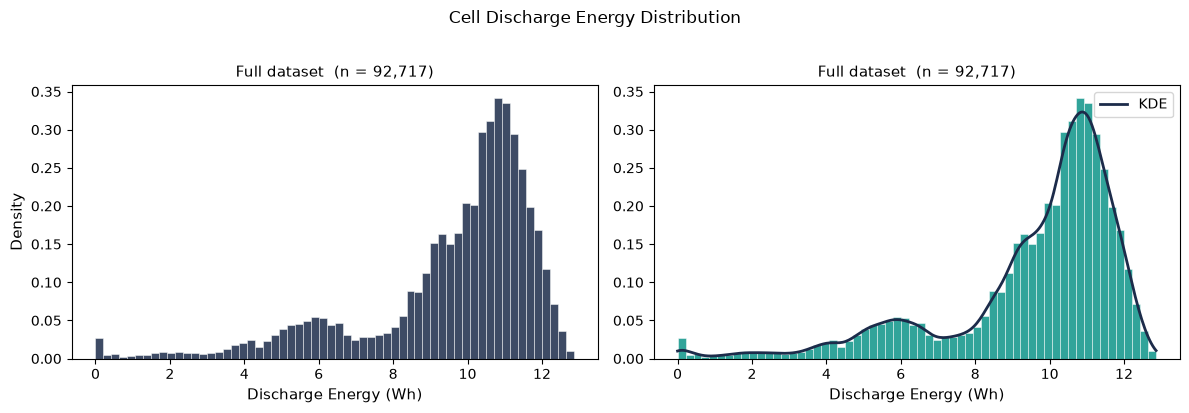

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df['discharge_energy_wh'].dropna(), bins=60, color='#1C2B4A', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Discharge Energy (Wh)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title(f'Full dataset  (n = {df["discharge_energy_wh"].notna().sum():,})', fontsize=11)

axes[1].hist(df['discharge_energy_wh'], bins=60, color='#0D9488', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
from scipy.stats import gaussian_kde
x_kde = np.linspace(df['discharge_energy_wh'].min(), df['discharge_energy_wh'].max(), 300)
axes[1].plot(x_kde, gaussian_kde(df['discharge_energy_wh'].dropna())(x_kde), color='#1C2B4A', lw=2, label='KDE')
axes[1].set_xlabel('Discharge Energy (Wh)', fontsize=11)
axes[1].set_title(f'Full dataset  (n = {df["discharge_energy_wh"].notna().sum():,})', fontsize=11)
axes[1].legend()

plt.suptitle('Cell Discharge Energy Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cell_discharge_energy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from scipy import stats

# Clean data
data = df['discharge_energy_wh'].dropna().values

# Normalize data to [0, 1] for Beta distribution
data_norm = (data - data.min()) / (data.max() - data.min())

# Test multiple distributions
results = []

# 1. Normal distribution (on original data)
params_norm = stats.norm.fit(data)
ks_norm = stats.kstest(data, lambda x: stats.norm.cdf(x, *params_norm))
results.append(('Normal', ks_norm.statistic, ks_norm.pvalue))

# 2. Beta distribution (on normalized data)
params_beta = stats.beta.fit(data_norm)
ks_beta = stats.kstest(data_norm, lambda x: stats.beta.cdf(x, *params_beta))
results.append(('Beta', ks_beta.statistic, ks_beta.pvalue))

print("\nGoodness-of-Fit Test Results:")
for dist_name, ks_stat, p_value in results:
    print(f"{dist_name}: KS Statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")
    



c:\Users\RXT0TKQ\AppData\Local\miniconda3\miniconda\envs\matds\Lib\site-packages\scipy\stats\_continuous_distns.py:806: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)



Goodness-of-Fit Test Results:
Normal: KS Statistic = 0.1530, p-value = 0.0000
Beta: KS Statistic = 0.1096, p-value = 0.0000


In [8]:
from scipy import stats
import numpy as np
import pandas as pd

data = df['discharge_energy_wh'].dropna().values
n = len(data)
data_norm = (data - data.min()) / (data.max() - data.min())

# Add small epsilon to avoid exact 0 and 1 boundaries for Beta distribution
eps = 1e-6
data_norm_safe = np.clip(data_norm, eps, 1 - eps)

# Fit distributions and compute BIC
results = []

# 1. Normal distribution
params_norm = stats.norm.fit(data)
loglik_norm = np.sum(stats.norm.logpdf(data, *params_norm))
k_norm = 2  # mu, sigma
bic_norm = k_norm * np.log(n) - 2 * loglik_norm
results.append({
    'Distribution': 'Normal',
    'Parameters': f'μ={params_norm[0]:.3f}, σ={params_norm[1]:.3f}',
    'Log-Likelihood': loglik_norm,
    'k (# params)': k_norm,
    'BIC': bic_norm
})

# 2. Beta distribution (fitted on normalized data, with safe boundaries)
params_beta = stats.beta.fit(data_norm_safe)
loglik_beta = np.sum(stats.beta.logpdf(data_norm_safe, params_beta[0], params_beta[1]))
k_beta = 2  # alpha, beta
bic_beta = k_beta * np.log(n) - 2 * loglik_beta
results.append({
    'Distribution': 'Beta',
    'Parameters': f'α={params_beta[0]:.3f}, β={params_beta[1]:.3f}',
    'Log-Likelihood': loglik_beta,
    'k (# params)': k_beta,
    'BIC': bic_beta
})

# 3. Gamma distribution
params_gamma = stats.gamma.fit(data)
loglik_gamma = np.sum(stats.gamma.logpdf(data, params_gamma[0], loc=params_gamma[1], scale=params_gamma[2]))
k_gamma = 2  # shape, scale
bic_gamma = k_gamma * np.log(n) - 2 * loglik_gamma
results.append({
    'Distribution': 'Gamma',
    'Parameters': f'shape={params_gamma[0]:.3f}, scale={params_gamma[2]:.3f}',
    'Log-Likelihood': loglik_gamma,
    'k (# params)': k_gamma,
    'BIC': bic_gamma
})

# 4. Skew-Normal distribution
params_skewnorm = stats.skewnorm.fit(data)
loglik_skewnorm = np.sum(stats.skewnorm.logpdf(data, params_skewnorm[0]))
k_skewnorm = 3  # skewness, mu, sigma
bic_skewnorm = k_skewnorm * np.log(n) - 2 * loglik_skewnorm
results.append({
    'Distribution': 'Skew-Normal',
    'Parameters': f'skew={params_skewnorm[0]:.3f}, μ={params_skewnorm[1]:.3f}, σ={params_skewnorm[2]:.3f}',
    'Log-Likelihood': loglik_skewnorm,
    'k (# params)': k_skewnorm,
    'BIC': bic_skewnorm
})

# Create DataFrame and sort by BIC (lower is better)
bic_df = pd.DataFrame(results).sort_values('BIC')

print("\n" + "="*90)
print("BIC Model Comparison (Lower BIC = Better Fit)")
print("="*90)
print(bic_df.to_string(index=False))
print("\n" + "="*90)
print(f"Best model: {bic_df.iloc[0]['Distribution']} (BIC = {bic_df.iloc[0]['BIC']:.2f})")
print("="*90)

# Calculate BIC differences relative to best model
bic_df['ΔBIC'] = bic_df['BIC'] - bic_df['BIC'].min()
print("\nBIC Differences from Best Model:")
print(bic_df[['Distribution', 'BIC', 'ΔBIC']].to_string(index=False))
print("\nInterpretation:")
print("- ΔBIC < 2: Essentially equivalent support")
print("- ΔBIC 2-7: Considerably less support")
print("- ΔBIC > 10: Essentially no support")



BIC Model Comparison (Lower BIC = Better Fit)
Distribution                      Parameters  Log-Likelihood  k (# params)           BIC
        Beta                α=5.644, β=1.678    2.743886e+04             2 -5.485484e+04
      Normal                μ=9.593, σ=2.349   -2.107476e+05             2  4.215180e+05
       Gamma      shape=237.683, scale=0.163   -2.141356e+05             2  4.282940e+05
 Skew-Normal skew=-11.029, μ=12.192, σ=3.503   -5.551144e+08             3  1.110229e+09

Best model: Beta (BIC = -54854.84)

BIC Differences from Best Model:
Distribution           BIC         ΔBIC
        Beta -5.485484e+04 0.000000e+00
      Normal  4.215180e+05 4.763729e+05
       Gamma  4.282940e+05 4.831489e+05
 Skew-Normal  1.110229e+09 1.110284e+09

Interpretation:
- ΔBIC < 2: Essentially equivalent support
- ΔBIC 2-7: Considerably less support
- ΔBIC > 10: Essentially no support


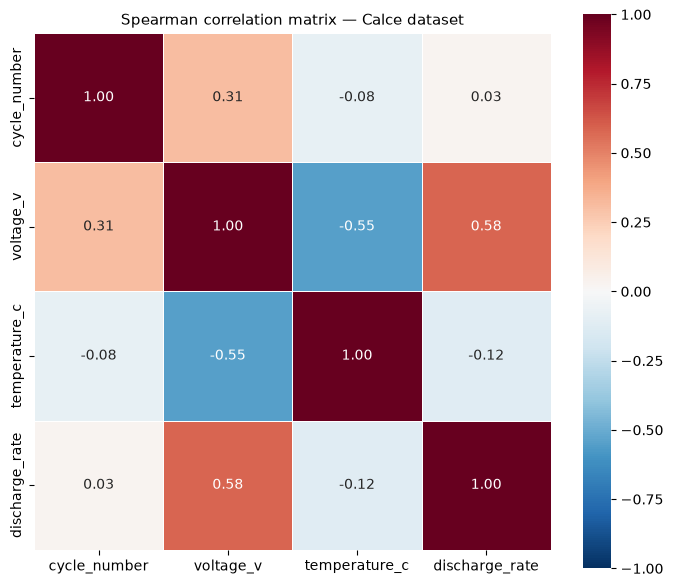

Spearman correlation matrix:
                cycle_number  voltage_v  temperature_c  discharge_rate
cycle_number           1.000      0.308         -0.085           0.030
voltage_v              0.308      1.000         -0.550           0.582
temperature_c         -0.085     -0.550          1.000          -0.121
discharge_rate         0.030      0.582         -0.121           1.000


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features (exclude categorical columns: sample_number, charge_cutoff)
numeric_features = [col for col in feature_cols if col not in ['sample_number', 'charge_cutoff']]
corr = df[numeric_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Spearman correlation matrix — Calce dataset', fontsize=11)
plt.tight_layout()
plt.savefig('Spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spearman correlation matrix:")
print(corr.round(3))

In [10]:
Q1  = df['discharge_energy_wh'].quantile(0.25)
Q3  = df['discharge_energy_wh'].quantile(0.75)
IQR_val = Q3 - Q1
lo  = Q1 - 1.5 * IQR_val
hi  = Q3 + 1.5 * IQR_val

outliers = df[((df['discharge_energy_wh'] < lo) | (df['discharge_energy_wh'] > hi))]

print(f"Q1 = {Q1:.3f} Wh   Q3 = {Q3:.3f} Wh   IQR = {IQR_val:.3f} Wh")
print(f"IQR fences: lower = {lo:.3f} Wh   upper = {hi:.3f} Wh")
print(f"Flagged as outliers: {len(outliers):,}  ({100*len(outliers)/len(df):.1f}% of dataset)")
print()
print("10 largest energy outliers:")
print(outliers.nsmallest(10, 'discharge_energy_wh')[['sample_number','discharge_energy_wh','cycle_number']].to_string(index=False))

Q1 = 8.953 Wh   Q3 = 11.132 Wh   IQR = 2.179 Wh
IQR fences: lower = 5.684 Wh   upper = 14.400 Wh
Flagged as outliers: 8,272  (8.9% of dataset)

10 largest energy outliers:
sample_number  discharge_energy_wh  cycle_number
       01-006                  0.0          27.0
       01-006                  0.0          33.0
       02-009                  0.0         401.0
       03-017                  0.0         665.0
       04-027                  0.0          74.0
       05-033                  0.0         166.0
       05-033                  0.0         213.0
       05-033                  0.0         214.0
       05-033                  0.0         216.0
       05-033                  0.0         236.0


In [11]:
# should I exclude outliers with 0 discharge energy? yes i think so cause the file shows subsequent cycles returning to a normal discharge energy after the 0 value. This suggests that the 0 value is likely an anomaly or error in the data collection process, rather than a true representation of the battery's performance. Excluding these outliers will provide a more accurate analysis of the battery's discharge energy distribution and improve the reliability of any statistical models built on this data.

In [12]:
df = df[df['discharge_energy_wh'] > 0.5]
df.describe()

,cycle_number,voltage_v,discharge_energy_wh,temperature_c,cycle_number_local,condition_id,discharge_rate
count,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000
mean,284.199285,3.541984,9.666919,32.423287,25.289949,11.370754,1.192198
std,180.921741,0.185716,2.204754,18.267374,14.432654,6.401746,0.539129
min,1.000000,2.999993,0.502525,10.000000,1.000000,1.000000,0.700000
25%,129.000000,3.374505,8.993271,10.000000,13.000000,6.000000,0.700000
50%,266.000000,3.618751,10.363900,25.000000,25.000000,12.000000,1.000000
75%,426.000000,3.676163,11.138110,45.000000,38.000000,17.000000,2.000000
max,750.000000,4.293325,12.860190,60.000000,50.000000,24.000000,2.000000


In [13]:
Q1  = df['discharge_energy_wh'].quantile(0.25)
Q3  = df['discharge_energy_wh'].quantile(0.75)
IQR_val = Q3 - Q1
lo  = Q1 - 1.5 * IQR_val
hi  = Q3 + 1.5 * IQR_val

outliers = df[((df['discharge_energy_wh'] < lo) | (df['discharge_energy_wh'] > hi))]

print(f"Q1 = {Q1:.3f} Wh   Q3 = {Q3:.3f} Wh   IQR = {IQR_val:.3f} Wh")
print(f"IQR fences: lower = {lo:.3f} Wh   upper = {hi:.3f} Wh")
print(f"Flagged as outliers: {len(outliers):,}  ({100*len(outliers)/len(df):.1f}% of dataset)")
print()
print("10 largest energy outliers:")
print(outliers.nsmallest(10, 'discharge_energy_wh')[['sample_number','discharge_energy_wh','cycle_number']].to_string(index=False))

Q1 = 8.993 Wh   Q3 = 11.138 Wh   IQR = 2.145 Wh
IQR fences: lower = 5.776 Wh   upper = 14.355 Wh
Flagged as outliers: 7,993  (8.7% of dataset)

10 largest energy outliers:
sample_number  discharge_energy_wh  cycle_number
       14-112             0.502525         432.0
       14-112             0.503842         425.0
       14-112             0.504604         424.0
       14-112             0.506823         423.0
       14-112             0.507192         431.0
       14-112             0.507979         422.0
       14-112             0.510167         421.0
       14-112             0.511501         419.0
       14-112             0.512814         420.0
       14-112             0.515710         418.0


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GroupKFold, cross_val_score,
    RandomizedSearchCV, learning_curve, train_test_split)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df_clean=df.copy()

# Convert charge_cutoff to numeric (preserve physical meaning)
# 'C/5' → 1/5 = 0.20,  'C/40' → 1/40 = 0.025
def charge_cutoff_to_numeric(val):
    if pd.isna(val):
        return None
    denominator = int(val.split('/')[1])
    return 1.0 / denominator

df_clean['charge_cutoff_numeric'] = df_clean['charge_cutoff'].apply(charge_cutoff_to_numeric)

# discharge_rate is already numeric (0.7C, 1C, 2C in C-rate form)
# Model features: exclude 'sample_number' and 'charge_cutoff', use 'charge_cutoff_numeric'
model_features = ['cycle_number', 'voltage_v', 'temperature_c', 'discharge_rate', 'charge_cutoff_numeric']

X_all = df_clean[model_features].values
y_all = df_clean['discharge_energy_wh'].values

groups = df_clean['sample_number'].values
gkf    = GroupKFold(n_splits=5)

folds = list(gkf.split(X_all, y_all, groups))
train_idx, test_idx = folds[0]

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
groups_train    = groups[train_idx]

print(f"Fold 0 - Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train mean discharge_energy_wh: {y_train.mean():.3f} Wh")
print(f"Test  mean discharge_energy_wh: {y_test.mean():.3f} Wh")

# Confirm no composition overlap between train and test
train_formulas = set(df_clean.iloc[train_idx]['sample_number'])
test_formulas  = set(df_clean.iloc[test_idx]['sample_number'])
overlap = train_formulas & test_formulas
print(f"\nComposition overlap between train and test: {len(overlap)} formulas")
print("(Should be 0 - that is the point of GroupKFold)")

Fold 0 - Train: 73,599  |  Test: 18,400
Train mean discharge_energy_wh: 9.686 Wh
Test  mean discharge_energy_wh: 9.590 Wh

Composition overlap between train and test: 0 formulas
(Should be 0 - that is the point of GroupKFold)


In [15]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))
])

r2_random = cross_val_score(pipe, X_all, y_all, cv=5, scoring="r2")

r2_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="r2")

mae_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="neg_mean_absolute_error")

rmse_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="neg_root_mean_squared_error")

print("=" * 50)
print(f"Random 5-fold CV R2:  {r2_random.mean():.3f} ± {r2_random.std():.3f}")
print(f"GroupKFold R2:        {r2_group.mean():.3f}  ± {r2_group.std():.3f}")
print(f"Inflation from random split: {r2_random.mean() - r2_group.mean():.3f}")

print(f"GroupKFold MAE:       {-mae_group.mean():.3f} ± {-mae_group.std():.3f}")
print(f"GroupKFold RMSE:      {-rmse_group.mean():.3f} ± {-rmse_group.std():.3f}")
print("=" * 50)




Random 5-fold CV R2:  -0.274 ± 1.743
GroupKFold R2:        0.993  ± 0.003
Inflation from random split: -1.267
GroupKFold MAE:       0.068 ± -0.005
GroupKFold RMSE:      0.185 ± -0.034


In [16]:
# Cell B3
# LECTURE DEMO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test

print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"X_test_scaled  mean: {X_test_scaled.mean():.4f}  (not guaranteed ~0)")

X_train_scaled mean: 0.0000  std: 1.0000
X_test_scaled  mean: 0.0046  (not guaranteed ~0)


In [17]:
rf_default = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_default.fit(X_train_scaled, y_train)
y_pred_default = rf_default.predict(X_test_scaled)

r2_def  = r2_score(y_test, y_pred_default)
mae_def = mean_absolute_error(y_test, y_pred_default)
rmse_def= np.sqrt(mean_squared_error(y_test, y_pred_default))

print("Default RF:")
print(f"  R2:   {r2_def:.3f}")
print(f"  MAE:  {mae_def:.3f} eV")
print(f"  RMSE: {rmse_def:.3f} eV")

Default RF:
  R2:   0.991
  MAE:  0.074 eV
  RMSE: 0.195 eV


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "rf__n_estimators":     [100, 200, 300, 500],
    "rf__max_depth":        [None, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features":     ["sqrt", "log2", 0.3],
}

rscv = RandomizedSearchCV(
    pipe, param_dist, n_iter=15,
    cv=GroupKFold(n_splits=5),
    scoring="r2", n_jobs=-1, random_state=42, verbose=0
)
rscv.fit(X_train, y_train, groups=groups_train)

best_model    = rscv
best_params   = rscv.best_params_
best_cv_score = rscv.best_score_
print("Method: RandomizedSearchCV (15 random trials)")

Method: RandomizedSearchCV (15 random trials)


In [27]:
y_pred_tuned = best_model.predict(X_test)
r2_tuned   = r2_score(y_test, y_pred_tuned)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

comparison = pd.DataFrame({
    'Model':  ['Default RF', 'Tuned RF (RandomizedSearch)'],
    'R2':     [round(r2_def,3),   round(r2_tuned,3)],
    'MAE':    [round(mae_def,3),  round(mae_tuned,3)],
    'RMSE':   [round(rmse_def,3), round(rmse_tuned,3)],
})
print(comparison.to_string(index=False))


                      Model    R2   MAE  RMSE
                 Default RF 0.991 0.074 0.195
Tuned RF (RandomizedSearch) 0.990 0.074 0.212


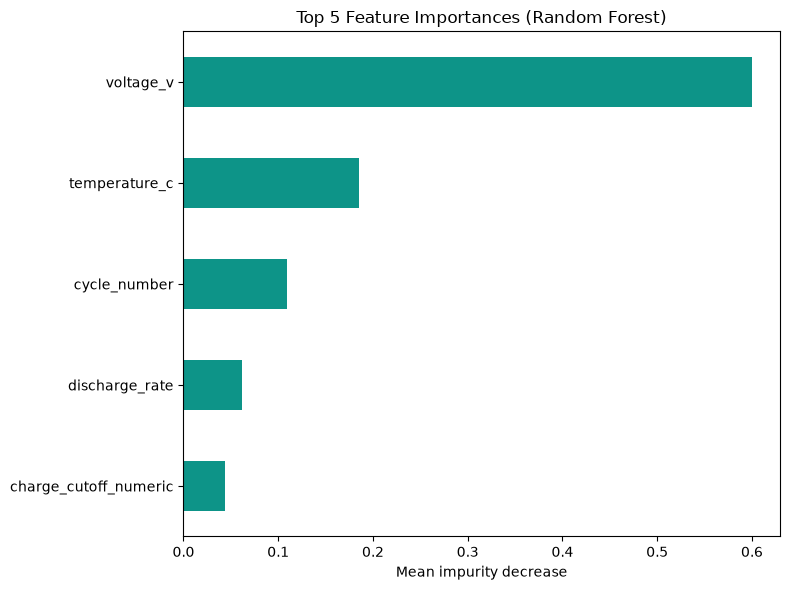

Top 5 features:
voltage_v                0.5996
temperature_c            0.1856
cycle_number             0.1093
discharge_rate           0.0620
charge_cutoff_numeric    0.0435
dtype: float64


In [25]:
best_rf = rscv.best_estimator_.named_steps['rf']
importances = pd.Series(best_rf.feature_importances_, index=model_features)
top = importances.nlargest(5)

fig, ax = plt.subplots(figsize=(8, 6))
top.sort_values().plot(kind='barh', color='#0D9488', ax=ax)
ax.set_xlabel('Mean impurity decrease')
ax.set_title('Top 5 Feature Importances (Random Forest)', fontsize=12)
plt.tight_layout()
plt.savefig('D1_feature_importance.png', dpi=150)
plt.show()

print("Top 5 features:")
print(top.head(5).round(4))

In [28]:
all_y_test = []
all_y_pred = []

for train_idx, test_idx in GroupKFold(n_splits=5).split(X_all, y_all, groups):
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_all[train_idx])
    X_test_fold = scaler.transform(X_all[test_idx])

    model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    model.fit(X_train_fold, y_all[train_idx])
    preds = model.predict(X_test_fold)

    all_y_test.append(y_all[test_idx])
    all_y_pred.append(preds)

all_y_test = np.concatenate(all_y_test)
all_y_pred = np.concatenate(all_y_pred)

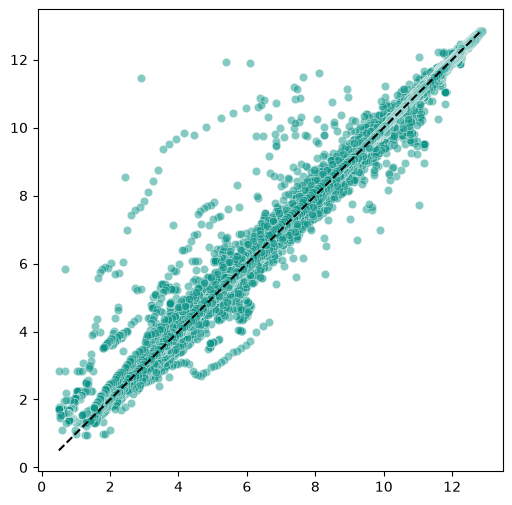

In [30]:
fig,ax = plt.subplots(figsize=(6, 6))

ax.scatter(all_y_test, all_y_pred, alpha=0.5, color='#0D9488', edgecolor='white', linewidth=0.4)

lims = [
min(all_y_test.min(), all_y_pred.min()),
max(all_y_test.max(), all_y_pred.max())
]
plt.plot(lims, lims, 'k--')
plt.show()